# Comprensión de los datos y EDA

Análisis exploratorio del dataset de créditos.
Variable objetivo: `Pago_atiempo`.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Permite visualizar todas las columnas de los DataFrames.
pd.set_option("display.max_columns", None)

# Configura un estilo uniforme para los gráficos.
sns.set_theme(style="whitegrid")

# Obtiene la carpeta raíz del proyecto desde la ubicación actual.
RUTA_PROYECTO = Path.cwd().parent.parent

# Carga la base de datos principal del proyecto.
df = pd.read_csv(RUTA_PROYECTO / "Base_de_datos.csv")

# Verifica las dimensiones de los datos cargados.
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Filas: 10763 | Columnas: 23


## Estructura general

In [64]:
# Muestra tipos de datos, cantidad de valores no nulos y uso de memoria.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  float64
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

## Resumen de todas las variables

In [65]:
# Construye un resumen de calidad y cardinalidad para cada columna.
resumen = pd.DataFrame({
    "tipo_pandas": df.dtypes.astype(str),              # Tipo de dato de cada columna.
    "no_nulos": df.notna().sum(),                      # Cantidad de valores no nulos.
    "nulos": df.isna().sum(),                          # Cantidad de valores nulos.
    "pct_nulos": (df.isna().mean() * 100).round(1),    # Porcentaje de valores nulos.
    "valores_unicos": df.nunique()                     # Cantidad de valores distintos.
})

# Ordena las columnas desde el mayor hasta el menor porcentaje de valores nulos.
resumen.sort_values("pct_nulos", ascending=False)

,tipo_pandas,no_nulos,nulos,pct_nulos,valores_unicos
promedio_ingresos_datacredito,float64,7833,2930,27.2,5309
tendencia_ingresos,str,7831,2932,27.2,46
saldo_mora_codeudor,float64,10173,590,5.5,4
saldo_principal,float64,10358,405,3.8,8647
saldo_mora,float64,10607,156,1.4,55
saldo_total,float64,10607,156,1.4,8858
puntaje_datacredito,float64,10757,6,0.1,315
salario_cliente,int64,10763,0,0.0,1385
tipo_laboral,str,10763,0,0.0,2
edad_cliente,int64,10763,0,0.0,54


### Observaciones

**Huecos.** Cinco columnas tienen faltantes, en dos escalas muy distintas:

- `promedio_ingresos_datacredito` (2.930, 27,2%) y `tendencia_ingresos`(2.932, 27,2%) — casi tres de cada diez registros. 
  
  Difieren en dos filas, así que probablemente falten en los mismos créditos.

- `saldo_mora_codeudor` (590), `saldo_principal` (405), `saldo_mora` y `saldo_total` (156 cada una) — manejables.

**Poca variedad.**

- `saldo_mora_codeudor`: 4 valores distintos en 10.173 registros.

- `saldo_mora`: 55 valores, frente a los 8.858 de `saldo_total` sobre la misma cantidad de filas. Dos columnas de montos que se comportan muy distinto.

- `tipo_laboral`: 2 valores, es dicotómica.

- `tipo_credito`: 6 valores y figura como `int64`. Son códigos de categoría, no cantidades — su promedio no significa nada.

**Demasiada variedad.** `tendencia_ingresos` tiene 46 valores únicos cuando debería tener 3. 

Se coló algo que no corresponde.

**La fecha.** `fecha_prestamo` tiene 10.758 valores sobre 10.763 registros: incluye la hora, así que no se repite. 

Funciona como identificador, no como predictor. Para usarla hay que derivar el mes o el año.

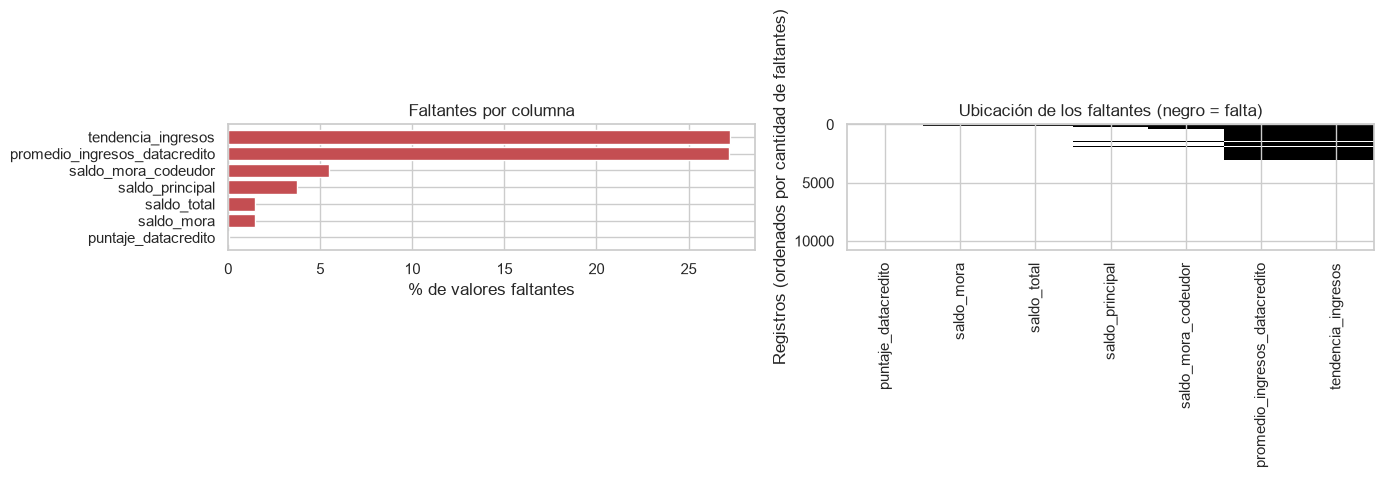

In [66]:
# Calcula el porcentaje de valores nulos por columna y conserva solo las columnas afectadas.
nulos_pct = (df.isna().mean() * 100).sort_values()
nulos_pct = nulos_pct[nulos_pct > 0]

# Crea una figura con un gráfico resumen y un mapa de distribución de faltantes.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Representa el porcentaje de valores faltantes de cada columna.
axes[0].barh(nulos_pct.index, nulos_pct.values, color="#c44e52")
axes[0].set_xlabel("% de valores faltantes")
axes[0].set_title("Faltantes por columna")

# Selecciona las columnas con nulos y ordena los registros por cantidad de faltantes.
con_nulos = df[nulos_pct.index]
orden = con_nulos.isna().sum(axis=1).sort_values(ascending=False).index

# Muestra la ubicación de los valores faltantes; el color negro indica un dato ausente.
axes[1].imshow(
    con_nulos.loc[orden].isna().values,
    aspect="auto",
    cmap="gray_r",
    interpolation="nearest"
)
axes[1].set_xticks(range(len(nulos_pct.index)))
axes[1].set_xticklabels(nulos_pct.index, rotation=90)
axes[1].set_ylabel("Registros (ordenados por cantidad de faltantes)")
axes[1].set_title("Ubicación de los faltantes (negro = falta)")

# Ajusta el diseño para evitar solapamientos y muestra la figura.
plt.tight_layout()
plt.show()

### Observaciones

El mapa de la derecha ordena los registros por cantidad de faltantes, así que
los más incompletos quedan arriba.

**`promedio_ingresos_datacredito` y `tendencia_ingresos` faltan juntas.** El
bloque negro sólido muestra que cuando falta una, falta la otra, en los mismos
~2.930 registros. No son dos faltantes independientes sino un único evento: el
cliente no tiene información en Datacrédito, y eso arrastra las dos variables
que provienen de esa fuente.

Los faltantes de `saldo_principal`, `saldo_mora_codeudor`, `saldo_total` y
`saldo_mora` son pocos y se concentran en registros que ya son incompletos.

**Más del 70% del dataset no tiene ningún valor faltante.**

## Análisis de anomalías

In [67]:
# Inspecciona las columnas problemáticas detectadas en el resumen anterior.
print("--- tipo_laboral ---")
print(df["tipo_laboral"].value_counts())  # Cuenta la frecuencia de cada categoría.

print("\n--- tipo_credito ---")
print(df["tipo_credito"].value_counts())  # Cuenta la frecuencia de cada tipo de crédito.

print("\n--- saldo_mora_codeudor ---")
print(
    df["saldo_mora_codeudor"].value_counts(dropna=False)
)  # Incluye los valores nulos en el recuento.

print("\n--- saldo_mora (top 10) ---")
print(
    df["saldo_mora"].value_counts().head(10)
)  # Muestra los diez valores más frecuentes.

--- tipo_laboral ---
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

--- tipo_credito ---
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

--- saldo_mora_codeudor ---
saldo_mora_codeudor
0.0       10170
NaN         590
2145.0        1
30.0          1
470.0         1
Name: count, dtype: int64

--- saldo_mora (top 10) ---
saldo_mora
0.0       10552
30.0          2
132.0         1
366.0         1
5721.0        1
67.0          1
2145.0        1
238.0         1
63.0          1
4379.0        1
Name: count, dtype: int64


### Observaciones

- **`saldo_mora_codeudor`**: 10.170 de 10.173 registros son 0 (99,97%). 
Solo tres tienen otro valor. Con esa variabilidad casi no distingue entre clientes, aunque conviene evaluarlo antes de descartarla.

- **`saldo_mora`**: 10.552 de 10.607 son 0 (99,5%). 
Además del mismo problema, arrastra uno peor: un saldo vencido es consecuencia del incumplimiento, no un antecedente. 
Cuando llega una solicitud nueva ese dato todavía no existe, usarla sería darle al modelo información del futuro, así que se excluye.

- **`tipo_credito`**: los tipos 4 (7.747) y 9 (2.876) concentran el 99%.
Los tipos 10, 6 y 7 suman 139 registros y el tipo 68 aparece una sola vez, rompiendo la secuencia de los demás (4, 6, 7, 9, 10).
Una categoría con uno o dos casos puede quedar entera de un lado al particionar los datos.

- **`tipo_laboral`**: dicotómica (Empleado 6.754, Independiente 4.009), sin nulos y bien balanceada. 
La más limpia del dataset.

### Relación entre saldo_mora y saldo_mora_codeudor

In [68]:
# ¿Coinciden los casos con mora en titular y codeudor?
mora_titular = df["saldo_mora"] > 0                              # Crear booleano: ¿hay mora?
mora_codeudor = df["saldo_mora_codeudor"] > 0                    # Idem para codeudor

print("Titular con mora:", mora_titular.sum())                   # Contar True (mora)
print("Codeudor con mora:", mora_codeudor.sum())                 # Idem
print("Ambos con mora:", (mora_titular & mora_codeudor).sum())   # Contar registros con ambos en mora

# ¿Los nulos también coinciden?
print("\nNulos saldo_mora:", df["saldo_mora"].isna().sum())       # Contar NaN
print("Nulos saldo_mora_codeudor:", df["saldo_mora_codeudor"].isna().sum())
print("Nulos en ambas:", (df["saldo_mora"].isna() & df["saldo_mora_codeudor"].isna()).sum())

Titular con mora: 55
Codeudor con mora: 3
Ambos con mora: 3

Nulos saldo_mora: 156
Nulos saldo_mora_codeudor: 590
Nulos en ambas: 156


Los 3 casos con mora del codeudor son un subconjunto exacto de los 55 del titular: no hay ni un registro donde el codeudor esté en mora y el titular al día.

Tiene sentido — al codeudor se le reclama recién tras el incumplimiento del titular. Así que esta columna no agrega nada: sus 3 casos ya están contados en la otra.

Un detalle aparte: los 156 nulos de `saldo_mora` están contenidos en los 590 de `saldo_mora_codeudor`. Las 434 filas restantes serían créditos sin codeudor, donde el 0 no distingue entre "no debe" y "no hay codeudor".

### Relación entre saldo_total y saldo_principal

In [69]:
# Selecciona los registros que tienen ambos saldos informados.
saldos = df[["saldo_total", "saldo_principal"]].dropna()

# Compara cuántos registros presentan exactamente el mismo valor en ambos saldos.
iguales = (saldos["saldo_total"] == saldos["saldo_principal"]).sum()

print(f"Registros con ambos saldos: {len(saldos)}")
print(f"Valores idénticos: {iguales} ({iguales / len(saldos) * 100:.1f}%)")

# Mide la relación lineal entre el saldo total y el saldo principal.
print(f"Correlación: {saldos.corr().iloc[0, 1]:.4f}")

Registros con ambos saldos: 10358
Valores idénticos: 8658 (83.6%)
Correlación: 0.7347


### Observaciones

De los 10.358 registros con ambos saldos informados, el 83,6% tiene valores idénticos, pero la correlación es 0,7347.

Esa aparente contradicción se explica por el 16% restante: ahí la diferencia entre ambos saldos es grande, y la correlación es sensible a los valores extremos.

La lectura: la mayoría de los clientes debe únicamente capital, y ahí ambas columnas coinciden. En el 16% restante hay un componente adicional que el dataset no permite identificar.

No son redundantes, entonces se conservan las dos — con 0,73 tampoco hay problema de multicolinealidad. La diferencia entre ambas queda anotada como posible atributo derivado.

### Inspeccionar tendencia_ingresos

In [70]:
# Muestra las categorías más frecuentes de tendencia_ingresos,
# incluyendo los valores nulos para evaluar la calidad de la columna.
print(
    df["tendencia_ingresos"]
    .value_counts(dropna=False)
    .head(15)
)

print()

# Cuenta la cantidad de valores distintos, excluyendo los nulos.
print(
    "Total valores únicos:",
    df["tendencia_ingresos"].nunique()
)

tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
Name: count, dtype: int64

Total valores únicos: 46


### Observaciones

La columna tiene las tres categorías esperadas 
—Creciente (5.294), Decreciente (1.291), Estable (1.188)— más 2.932 nulos y **58 registros con números adentro**.

Esos números incluyen negativos (`-28589`, `-566272`) y montos altos (`1000000`, `158042`), en la misma escala que `salario_cliente` y `promedio_ingresos_datacredito`.

**Hipótesis, no verificable con los datos:** serían la variación de ingresos expresada como monto en lugar de su categoría. El signo encaja, pero no hay forma de confirmarlo.

**Por eso no se decide todavía.** Recodificar por signo se apoyaría entero en esa hipótesis. Las alternativas para la etapa de preparación:

1. Recodificar por signo (positivo → Creciente, negativo → Decreciente, cero → Estable), asumiendo la hipótesis.
2. Convertirlos a nulo, tratándolos como inválidos.
3. Darles categoría propia (`valor_anomalo`), preservando la condición sin interpretarla.
4. Excluir la variable, que ya tiene 27,2% de faltantes.

Son 58 registros sobre 10.763 (0,5%), así que el impacto de cualquiera de las cuatro es acotado.

## Duplicados

In [71]:
# Cuenta las filas completamente idénticas en todas sus columnas.
print("Duplicados exactos:", df.duplicated().sum())

Duplicados exactos: 0


## Estadísticos descriptivos

In [72]:
# Genera estadísticas descriptivas de las variables numéricas.
# La transposición facilita consultar cada variable por fila.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763.0,5.411131e+00,2.338279e+00,4.00000,4.000000e+00,4.000000e+00,9.000000e+00,6.800000e+01
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01


### Detección de anomalías y valores extremos

In [73]:
# Comprueba valores constantes o fuera de rango en variables potencialmente problemáticas.
print(
    "puntaje == 95.227787:",
    (df["puntaje"].round(6) == 95.227787).sum()
)
print("puntaje negativo:", (df["puntaje"] < 0).sum())

print()

# Detecta salarios codificados como cero y valores de ingresos extremos.
print("salario == 0:", (df["salario_cliente"] == 0).sum())
print("salario > 50 millones:", (df["salario_cliente"] > 50_000_000).sum())

print()

# Identifica edades improbables y puntajes fuera de un rango válido.
print("edad > 90:", (df["edad_cliente"] > 90).sum())
print("puntaje_datacredito < 0:", (df["puntaje_datacredito"] < 0).sum())

puntaje == 95.227787: 9407
puntaje negativo: 135

salario == 0: 24
salario > 50 millones: 97

edad > 90: 150
puntaje_datacredito < 0: 1


Los conteos anteriores se visualizan mejor en un boxplot: la caja es el 50%
central de los datos y los puntos sueltos son los valores atípicos.

C:\Users\mau93\AppData\Local\Temp\ipykernel_35788\377084777.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_35788\377084777.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_35788\377084777.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_35788\377084777.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientati

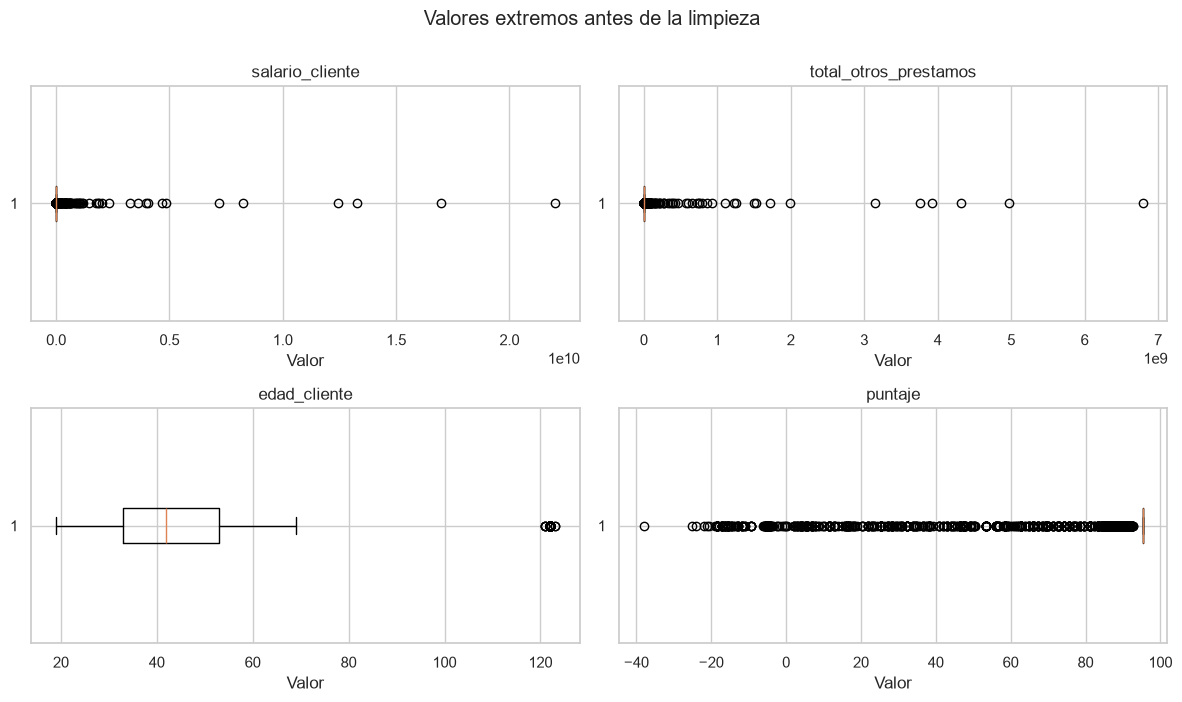

In [74]:
# Define las variables con posibles valores extremos.
extremos = ["salario_cliente", "total_otros_prestamos", "edad_cliente", "puntaje"]

# Crea una cuadrícula de cuatro gráficos.
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

# Genera un boxplot horizontal para cada variable.
for i, col in enumerate(extremos):
    # Elimina los valores nulos antes de graficar.
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")

# Ajusta el diseño y muestra los gráficos.
plt.suptitle("Valores extremos antes de la limpieza", y=1.00)
plt.tight_layout()
plt.show()

### Observaciones

**`salario_cliente` y `total_otros_prestamos`**: la caja se reduce a una línea
pegada al cero mientras los puntos se extienden hasta 22.000 y 6.787 millones.
Es la representación gráfica de los skew de 43,7 y 38,5.

**`edad_cliente` muestra un grupo separado, no una cola.** La caja es normal
—mediana en 42, bigotes hasta 69— y después hay un vacío completo entre 69 y
120 años, sin ningún registro. Los 150 casos atípicos aparecen agrupados en
120-123. Ese salto refuerza que se trata de un error sistemático de carga y no
de edades reales dispersas.

**`puntaje`**: la caja es prácticamente invisible porque el 87,4% de los
valores es el mismo número. Todo lo demás queda clasificado como atípico,
incluidos los 135 valores negativos que llegan hasta -38.

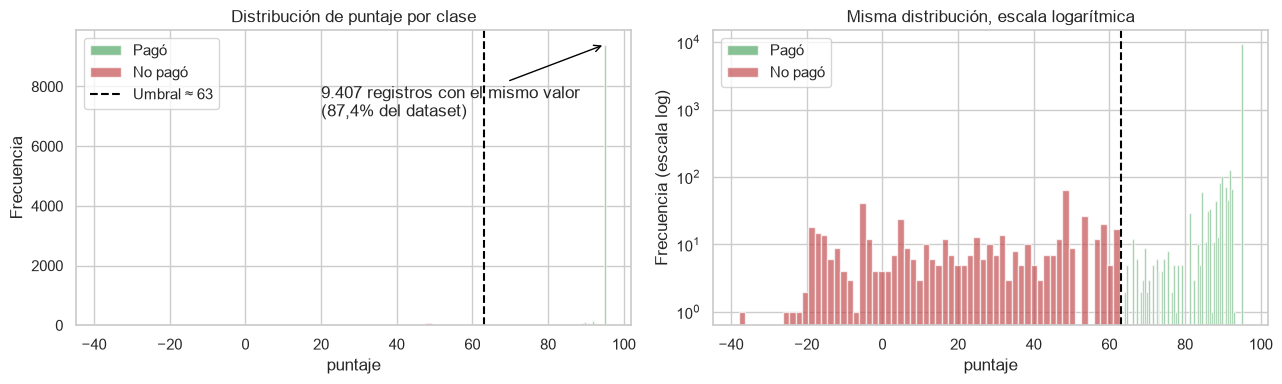

In [75]:
# Crea una figura con dos gráficos para comparar el puntaje por clase.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Genera histogramas superpuestos para los créditos pagados y no pagados.
for clase, color, etiqueta in [(1, "#55a868", "Pagó"), (0, "#c44e52", "No pagó")]:
    axes[0].hist(
        df.loc[df["Pago_atiempo"] == clase, "puntaje"],
        bins=60,
        alpha=0.7,
        color=color,
        label=etiqueta
    )

# Marca el umbral aproximado que separa las dos clases.
axes[0].axvline(63, color="black", linestyle="--", label="Umbral ≈ 63")
axes[0].set_xlabel("puntaje")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de puntaje por clase")
axes[0].legend()

# Anota la concentración de registros con el mismo valor de puntaje.
axes[0].annotate(
    "9.407 registros con el mismo valor\n(87,4% del dataset)",
    xy=(95, 9407),
    xytext=(20, 7000),
    arrowprops=dict(arrowstyle="->", color="black")
)

# Repite los histogramas en el segundo eje para usar una escala logarítmica.
for clase, color, etiqueta in [(1, "#55a868", "Pagó"), (0, "#c44e52", "No pagó")]:
    axes[1].hist(
        df.loc[df["Pago_atiempo"] == clase, "puntaje"],
        bins=60,
        alpha=0.7,
        color=color,
        label=etiqueta
    )

# Configura el segundo gráfico para resaltar frecuencias pequeñas.
axes[1].axvline(63, color="black", linestyle="--")
axes[1].set_yscale("log")
axes[1].set_xlabel("puntaje")
axes[1].set_ylabel("Frecuencia (escala log)")
axes[1].set_title("Misma distribución, escala logarítmica")
axes[1].legend()

# Ajusta el diseño y muestra la figura final.
plt.tight_layout()
plt.show()

### Observaciones sobre los estadísticos descriptivos

- **`puntaje`**: 
9.407 de 10.763 registros (87,4%) comparten el valor `95.227787`, que además es el máximo. 
Los percentiles 25, 50 y 75 coincidenen ese número.
Hay también 135 valores negativos, inválidos para un score.
  Se analiza aparte en la sección siguiente.

- **`salario_cliente`**: 
la media (17,2 M) quintuplica a la mediana (3,0 M), con desviación estándar de 355 M. 
Hay 97 registros por encima de 50 millones —el máximo llega a 22.000 millones— y 24 con salario 0, que para un titular
  de crédito no tiene sentido: probablemente sea un faltante escrito como cero.

- **`total_otros_prestamos`**: 
misma asimetría (media 6,2 M vs. mediana 1,0 M, máximo 6.787 M).

- **`edad_cliente`**: 
150 registros superan los 90 años, con máximo de 123.

- **`puntaje_datacredito`**:
un registro en -7, fuera del rango del score.

- **`Pago_atiempo`**:
media de 0,9525, o sea 95,25% de clase mayoritaria — solo 511 impagos sobre 10.763. Un modelo que prediga "paga" para todos acierta el 95% sin detectar un solo caso de riesgo. 
Por eso la evaluación tiene que apoyarse en recall y F1, nunca en accuracy.

### Relación de `puntaje` con la variable objetivo

La concentración de valores en `puntaje` motiva verificar si el valor constante
se asocia al resultado del crédito.

In [76]:
# Identifica los registros que tienen el valor constante de puntaje.
puntaje_constante = df["puntaje"].round(6) == 95.227787

# Compara la presencia del valor constante con el resultado del crédito.
print("Frecuencias:")
print(pd.crosstab(puntaje_constante, df["Pago_atiempo"]))

# Calcula el porcentaje de cada clase dentro de cada grupo de puntaje.
print("\nPorcentaje por fila:")
porcentajes = pd.crosstab(
    puntaje_constante,
    df["Pago_atiempo"],
    normalize="index"
) * 100
print(porcentajes.round(2))

# Resume la distribución del puntaje separando los créditos pagados
# de los que no fueron pagados a tiempo.
print("\nDistribución de puntaje por clase:")
distribucion = df.groupby("Pago_atiempo")["puntaje"].describe()
print(distribucion.round(2))

Frecuencias:
Pago_atiempo    0     1
puntaje                
False         511   845
True            0  9407

Porcentaje por fila:
Pago_atiempo      0       1
puntaje                    
False         37.68   62.32
True           0.00  100.00

Distribución de puntaje por clase:
                count   mean    std    min    25%    50%    75%    max
Pago_atiempo                                                          
0               511.0  23.09  26.07 -38.01  -3.59  25.42  47.61  62.67
1             10252.0  94.56   2.87  63.81  95.23  95.23  95.23  95.23


### Observaciones

**El valor constante separa perfectamente las clases.** 
Los 9.407 registros con `95.227787` pagaron a tiempo sin excepción. 
Los 511 impagos están íntegramente entre los 1.356 con valor distinto, donde el incumplimiento sube al 37,68%.

**Y los rangos no se solapan.** 
El máximo de `puntaje` entre los impagos es 62,67; el mínimo entre los que pagaron es 63,81. 
Un umbral en torno a 63 clasifica correctamente el 100% de los registros.

Ningún dato real predice el futuro sin equivocarse. 
Una separación perfecta significa que el valor se determinó después de conocer el resultado, o que directamente lo codifica. 
Si entra al entrenamiento, el modelo va a dar métricas casi perfectas en las pruebas y a fallar con clientes nuevos, porque
ese puntaje no existe al momento de la solicitud.

**Se excluye.** 
Y vale notar que la conclusión es la opuesta a la primera impresión: el problema de esta columna no es la falta de información sino su exceso.

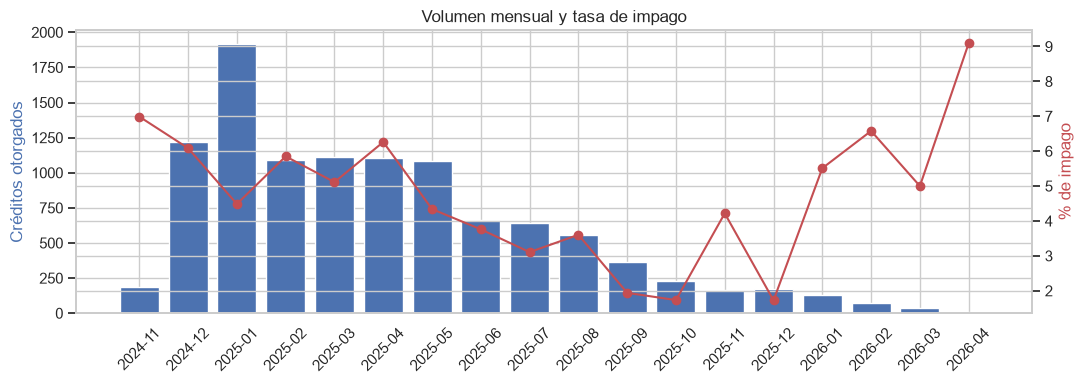

In [77]:
# Convierte las fechas y agrupa los créditos por mes.
fecha = pd.to_datetime(df["fecha_prestamo"])
por_mes = df.groupby(fecha.dt.to_period("M")).agg(
    # Cuenta la cantidad de créditos otorgados en cada mes.
    creditos=("Pago_atiempo", "size"),
    # Calcula el porcentaje mensual de créditos no pagados a tiempo.
    pct_impago=("Pago_atiempo", lambda x: (1 - x.mean()) * 100)
)

# Convierte los períodos mensuales a texto para usarlos en el eje X.
meses = por_mes.index.astype(str)

# Crea la figura y el primer eje para representar el volumen de créditos.
fig, ax1 = plt.subplots(figsize=(11, 4))

# Muestra la cantidad de créditos otorgados por mes mediante barras.
ax1.bar(meses, por_mes["creditos"], color="#4c72b0", label="Créditos")
ax1.set_ylabel("Créditos otorgados", color="#4c72b0")
ax1.tick_params(axis="x", rotation=45)

# Crea un segundo eje Y para representar el porcentaje de impago.
ax2 = ax1.twinx()

# Muestra la evolución mensual de la tasa de impago mediante una línea.
ax2.plot(
    meses,
    por_mes["pct_impago"],
    color="#c44e52",
    marker="o",
    label="% impago"
)
ax2.set_ylabel("% de impago", color="#c44e52")

# Ajusta el diseño y muestra el gráfico combinado.
plt.title("Volumen mensual y tasa de impago")
plt.tight_layout()
plt.show()

### Observaciones

El gráfico superpone las dos series y deja ver la relación entre ellas.

Las barras muestran el descenso del volumen: crece hasta enero de 2025 (1.917
créditos) y cae sostenidamente hasta abril de 2026 (11).

La línea de impago forma una U: baja del 7,0% al 1,7% entre noviembre de 2024 y
diciembre de 2025, y luego sube hasta el 9,1%. **Esa subida coincide
exactamente con los meses de menor volumen.** Los últimos cinco puntos se
calculan sobre 174, 127, 76, 40 y 11 registros: el 9,1% final corresponde a un
único crédito.

La bajada inicial sí tiene respaldo —esos meses tienen entre 500 y 1.900
registros— y es compatible con que los créditos más recientes hayan tenido
menos tiempo para entrar en mora, aunque no se verificó.

## Variable temporal

In [78]:
# Convierte la columna de fechas al formato datetime para poder analizarla.
fechas = pd.to_datetime(df["fecha_prestamo"])

# Muestra la primera y la última fecha registrada en el dataset.
print("Desde:", fechas.min())
print("Hasta:", fechas.max())

# Calcula la duración total del período analizado en días.
print("Rango:", (fechas.max() - fechas.min()).days, "días")

print()

# Agrupa las fechas por mes y cuenta la cantidad de créditos en cada período.
creditos_por_mes = fechas.dt.to_period("M").value_counts().sort_index()
print(creditos_por_mes)

Desde: 2024-11-26 09:17:04
Hasta: 2026-04-26 18:43:52
Rango: 516 días

fecha_prestamo
2024-11     186
2024-12    1216
2025-01    1917
2025-02    1094
2025-03    1115
2025-04    1102
2025-05    1083
2025-06     665
2025-07     644
2025-08     555
2025-09     361
2025-10     231
2025-11     166
2025-12     174
2026-01     127
2026-02      76
2026-03      40
2026-04      11
Freq: M, Name: count, dtype: int64


### Cruce mensual con otras variables

In [79]:
# Crea una copia del DataFrame para no modificar los datos originales.
df_temp = df.copy()

# Extrae el período mensual a partir de la fecha de cada crédito.
df_temp["mes"] = pd.to_datetime(
    df_temp["fecha_prestamo"]
).dt.to_period("M")

# Agrupa los registros por mes y calcula indicadores temporales.
resumen_mes = df_temp.groupby("mes").agg(
    # Cantidad total de créditos otorgados en cada mes.
    creditos=("Pago_atiempo", "size"),

    # Porcentaje de créditos que no se pagaron a tiempo.
    pct_impago=("Pago_atiempo", lambda x: (1 - x.mean()) * 100),

    # Porcentaje mensual de valores faltantes en los ingresos reportados.
    pct_nulos_ingresos=(
        "promedio_ingresos_datacredito",
        lambda x: x.isna().mean() * 100
    ),

    # Porcentaje mensual de valores faltantes en el saldo principal.
    pct_nulos_saldo=(
        "saldo_principal",
        lambda x: x.isna().mean() * 100
    ),

    # Salario mediano de los clientes de cada mes.
    salario_medio=("salario_cliente", "median"),

    # Edad promedio de los clientes de cada mes.
    edad_media=("edad_cliente", "mean")
).round(1)

# Muestra el resumen mensual de volumen, riesgo y calidad de los datos.
resumen_mes

,creditos,pct_impago,pct_nulos_ingresos,pct_nulos_saldo,salario_medio,edad_media
mes,,,,,,
2024-11,186,7.0,32.8,6.5,2500000.0,42.0
2024-12,1216,6.1,31.9,3.5,2800000.0,43.1
2025-01,1917,4.5,26.2,2.5,3000000.0,44.0
2025-02,1094,5.9,23.7,3.7,3000000.0,44.2
2025-03,1115,5.1,26.1,3.8,3100000.0,44.2
2025-04,1102,6.3,27.0,3.4,3100000.0,44.4
2025-05,1083,4.3,27.3,5.2,3500000.0,45.1
2025-06,665,3.8,26.2,5.6,3500000.0,45.0
2025-07,644,3.1,35.6,4.7,3000000.0,44.3


### Observaciones

El dataset abarca 516 días, del 26/11/2024 al 26/04/2026. 

El volumen mensual cae de forma sostenida: 
**1.917 créditos en enero de 2025 contra 11 en abril de 2026**. 
Ninguna financiera real pierde el 99% de su actividad en línea recta, así que probablemente sea un efecto de cómo se armó el archivo.

Probamos dos explicaciones y ninguna encaja:

1. **Maduración de los créditos.** 
Si los meses recientes trajeran solo créditos de plazo corto —los únicos ya vencidos— el plazo promedio debería bajar. 
Pasalo contrario: 
baja hasta 9,2 meses en junio de 2025 y después sube hasta 16,5 en enero de 2026. 
Esto no descarta del todo un efecto de maduración:
comprobarlo requeriría la fecha de extracción, que el dataset no incluye.

2. **Corte abrupto en la extracción.** 
Un corte daría actividad normal hasta cierto día y nada después. 
Los registros siguen apareciendo hasta el final, cada vez más espaciados:
en enero de 2026 hay créditos casi todos los días,en abril quedan nueve días con uno cada uno. 
Descarta el corte abrupto, pero no una carga parcial, un ETL incompleto o un filtro desconocido — cualquiera de esos produce justamente un descenso gradual.

**Otros datos de la tabla mensual.** 
La tasa de impago baja del 7,0% en noviembre de 2024 al 1,7% en octubre y diciembre de 2025. 
Una explicación posible, no verificada acá, es que los créditos recientes hayan tenido menos tiempo para caer en mora. 
Los últimos meses (76, 40 y 11 registros) no son interpretables: 
el 9,1% de abril de 2026 es un único caso.

El perfil del cliente se mantiene estable en todo el período —salario mediano entre 2,5 y 3,5 M, edad promedio entre 40 y 45 años—, lo que descarta un cambio en la política de otorgamiento.

No hay información que permita determinar la causa ni descartar problemas de cobertura. 
Queda anotado para definir la estrategia de partición en el modelado.

## Patrón de los valores faltantes

In [80]:
# Crea una copia para añadir variables auxiliares sin modificar el DataFrame original.
df_temp = df.copy()

# Convierte la fecha del préstamo al formato datetime.
df_temp["fecha"] = pd.to_datetime(df_temp["fecha_prestamo"])

# Marca los registros que no tienen información de ingresos.
df_temp["sin_ingresos"] = (
    df_temp["promedio_ingresos_datacredito"].isna()
)

# Compara la fecha mediana de los registros con y sin información de ingresos.
fecha_con_ingresos = df_temp.loc[
    ~df_temp["sin_ingresos"], "fecha"
].median()

fecha_sin_ingresos = df_temp.loc[
    df_temp["sin_ingresos"], "fecha"
].median()

print("Con ingresos - fecha mediana:", fecha_con_ingresos)
print("Sin ingresos - fecha mediana:", fecha_sin_ingresos)

Con ingresos - fecha mediana: 2025-03-27 15:48:51
Sin ingresos - fecha mediana: 2025-03-28 12:08:57.500000


### Asociaciones de los datos faltantes

Los nulos no se distribuyen uniformemente. Ahora analizamos cómo se asocian con características del cliente y del riesgo de incumplimiento.

In [81]:
# Identifica los registros que no tienen información de ingresos.
df_temp["sin_ingresos"] = (
    df_temp["promedio_ingresos_datacredito"].isna()
)

# Calcula la proporción de valores faltantes según el tipo de empleo.
faltantes_por_empleo = (
    df_temp.groupby("tipo_laboral")["sin_ingresos"]
    .mean()
    .round(3)
)
print("Faltantes por tipo de empleo:")
print(faltantes_por_empleo)

print()

# Calcula la proporción de valores faltantes según el tipo de crédito.
faltantes_por_credito = (
    df_temp.groupby("tipo_credito")["sin_ingresos"]
    .mean()
    .round(3)
)
print("Faltantes por tipo de crédito:")
print(faltantes_por_credito)

print()

# Compara la tasa de impago entre clientes con y sin información de ingresos.
impago_con_ingresos = (
    1 - df_temp.loc[~df_temp["sin_ingresos"], "Pago_atiempo"].mean()
).round(4)

impago_sin_ingresos = (
    1 - df_temp.loc[df_temp["sin_ingresos"], "Pago_atiempo"].mean()
).round(4)

print("Impago con ingresos:", impago_con_ingresos)
print("Impago sin ingresos:", impago_sin_ingresos)

Faltantes por tipo de empleo:
tipo_laboral
Empleado         0.19
Independiente    0.41
Name: sin_ingresos, dtype: float64

Faltantes por tipo de crédito:
tipo_credito
4     0.252
6     0.190
7     0.500
9     0.329
10    0.250
68    0.000
Name: sin_ingresos, dtype: float64

Impago con ingresos: 0.0438
Impago sin ingresos: 0.0573


In [82]:
# Importa la prueba chi-cuadrado para evaluar la asociación entre variables categóricas.
from scipy.stats import chi2_contingency

# Construye una tabla de contingencia entre la ausencia de ingresos
# y el resultado del pago del crédito.
tabla = pd.crosstab(
    df["promedio_ingresos_datacredito"].isna(),
    df["Pago_atiempo"]
)

# Aplica la prueba chi-cuadrado de independencia.
chi2, p_valor, _, _ = chi2_contingency(tabla)

# Muestra la tabla observada y el p-valor de la prueba estadística.
print(tabla)
print(f"\np-valor: {p_valor:.4f}")

Pago_atiempo                     0     1
promedio_ingresos_datacredito           
False                          343  7490
True                           168  2762

p-valor: 0.0038


### Observaciones

**Sin concentración temporal.** 
La fecha mediana de los registros con dato de ingresos (2025-03-27) y la de los que no lo tienen (2025-03-28) difiere en un
día sobre un rango de 516. 
El aparente salto de nulos en los últimos meses —del 16,7% en diciembre de 2025 al 90,9% en abril de 2026— es un espejismo del
bajo volumen: ese 90,9% son 10 registros sobre 11.

**Sí se asocia al tipo laboral.** 
El 41% de los independientes no tiene el dato,contra el 19% de los empleados: más del doble. 
Una explicación posible —no verificable acá— es que verificar ingresos de un trabajador por cuenta propia es más difícil, porque no hay empleador que los reporte. 
Lo que sí queda establecido es más acotado: la ausencia no se reparte de manera uniforme entre los grupos observados. 
Determinar el mecanismo completo excede esta etapa.

**Y se asocia al impago.** 
Los registros sin dato fallan un 5,73% frente al 4,38% de los que sí lo tienen. 
Como la diferencia parecía chica, se midió con chi-cuadrado: 
**p-valor de 0,0038**, así que no se explica por azar. 
Igual la magnitud es moderada (1,35 puntos), de modo que queda establecida la asociación,no su peso como predictor.

Sobre `tipo_credito`, los faltantes van del 19% al 50%, pero solo los tipos 4 y 9 tienen volumen para sostener la comparación (25% y 33%) — y esa diferencia es coherente con el efecto del tipo laboral.

**Implicancia.** 
Al imputar `promedio_ingresos_datacredito` hay que agregar un indicador binario que preserve cuáles estaban vacíos.
Si se rellena y se olvida, esa señal se pierde.

## Limitaciones del dataset

No hay documentación de las variables, así que la interpretación de `tipo_credito`, `huella_consulta` o `puntaje` se apoya en convenciones del dominio y en lo que muestran los propios datos.

Dos puntos quedan abiertos:

- **`puntaje`**: 
no se puede determinar en qué momento del proceso se calcula.
La evidencia empírica —separación perfecta de las clases— alcanza igual para excluirla.

- **`tendencia_ingresos`**: 
no se puede determinar el origen de los 58 valores numéricos ni cuál es el tratamiento correcto.

## Limpieza de datos

Con los problemas ya documentados, se aplican las correcciones. El orden va de
lo menos invasivo a lo más: primero tipos y valores, y las eliminaciones al
final, para conservar las columnas disponibles por si hacen falta en alguna
verificación intermedia.

Se trabaja sobre una copia (`df_limpio`) para poder comparar contra el original.

In [83]:
# Crea una copia del DataFrame original para aplicar la limpieza
# sin modificar los datos de referencia.
df_limpio = df.copy()

# Confirma el tamaño del dataset utilizado para la limpieza.
print(
    f"Copia creada: {df_limpio.shape[0]} filas, "
    f"{df_limpio.shape[1]} columnas"
)

Copia creada: 10763 filas, 23 columnas


### Conversión de tipos

`fecha_prestamo` está almacenada como texto. Sin convertirla no se puede
ordenar cronológicamente ni derivar el mes o el año.

In [84]:
# Convierte la fecha del préstamo al formato datetime
# para permitir operaciones y análisis temporales.
df_limpio["fecha_prestamo"] = pd.to_datetime(
    df_limpio["fecha_prestamo"]
)

# Verifica el tipo de dato y el rango temporal disponible.
print("Tipo:", df_limpio["fecha_prestamo"].dtype)
print(
    "Rango:",
    df_limpio["fecha_prestamo"].min(),
    "→",
    df_limpio["fecha_prestamo"].max()
)

Tipo: datetime64[us]
Rango: 2024-11-26 09:17:04 → 2026-04-26 18:43:52


### Unificación de nulos

24 registros tienen `salario_cliente` en 0. Un titular de crédito con ingreso
declarado cero es inconsistente: lo más probable es que sea un dato faltante
representado como cero.

Se convierten a `NaN` para que queden registrados como lo que son. La decisión
de imputarlos o no se toma en la etapa de preparación, junto con el resto de
los faltantes.

In [85]:
# Cuenta los valores nulos existentes antes de la corrección.
antes = df_limpio["salario_cliente"].isna().sum()

# Convierte los salarios iguales a cero en valores faltantes,
# ya que no representan un ingreso válido para este análisis.
df_limpio.loc[
    df_limpio["salario_cliente"] == 0,
    "salario_cliente"
] = pd.NA

# Cuenta los valores nulos después de reemplazar los ceros.
despues = df_limpio["salario_cliente"].isna().sum()

# Compara la cantidad de nulos antes y después del tratamiento.
print(f"Nulos en salario_cliente: {antes} → {despues}")

Nulos en salario_cliente: 0 → 24


### Corrección de valores fuera de rango

Se convierten a nulo los valores imposibles en lugar de eliminar la fila: el
resto de las variables del registro es válido y descartarlo perdería esa
información.

- **`puntaje_datacredito`**: un registro con valor -7, fuera del rango del
  score.
- **`edad_cliente`**: 150 registros por encima de 90 años, con máximo de 123.
  No es que esa edad no exista, pero como titular de crédito activo es
  extremadamente improbable, y 150 casos son demasiados para ser reales.

Dos casos se conservan sin modificar:

- **`salario_cliente`**: los 97 registros por encima de 50 millones son
  atípicos, pero un ingreso alto no es imposible y no hay un umbral claro que
  separe lo raro de lo inválido. Se tratan como outliers en la etapa de
  preparación, mediante transformación de escala.
- **`tipo_credito` = 68**: un único registro. Se conserva por ser un caso
  aislado que no afecta el análisis.

In [86]:
# Reemplaza los puntajes negativos por NaN porque están fuera del rango válido.
df_limpio.loc[
    df_limpio["puntaje_datacredito"] < 0,
    "puntaje_datacredito"
] = np.nan

# Reemplaza las edades superiores a 90 años por NaN
# porque son valores implausibles para este análisis.
df_limpio.loc[
    df_limpio["edad_cliente"] > 90,
    "edad_cliente"
] = np.nan

# Muestra la cantidad de valores faltantes generados después de la limpieza.
print("Nulos generados:")
print(
    f"  puntaje_datacredito: "
    f"{df_limpio['puntaje_datacredito'].isna().sum()} (antes 6)"
)
print(
    f"  edad_cliente:        "
    f"{df_limpio['edad_cliente'].isna().sum()} (antes 0)"
)

Nulos generados:
  puntaje_datacredito: 7 (antes 6)
  edad_cliente:        150 (antes 0)


### Tratamiento de tendencia_ingresos

Antes de decidir qué hacer con los 58 registros numéricos, se verifica si
presentan algún comportamiento particular respecto de la variable objetivo.

In [87]:
# Convierte temporalmente tendencia_ingresos a numérico.
# Los valores numéricos representan registros anómalos.
anomalos = pd.to_numeric(
    df["tendencia_ingresos"],
    errors="coerce"
).notna()

# Cuenta cuántos registros contienen valores numéricos inesperados.
print(f"Registros anómalos: {anomalos.sum()}")

# Calcula la tasa de impago entre los registros anómalos.
impago_anomalos = (
    1 - df.loc[anomalos, "Pago_atiempo"].mean()
) * 100

# Calcula la tasa de impago entre los registros restantes.
impago_resto = (
    1 - df.loc[~anomalos, "Pago_atiempo"].mean()
) * 100

print(f"Impago en anómalos: {impago_anomalos:.2f}%")
print(f"Impago en el resto:  {impago_resto:.2f}%")

Registros anómalos: 58
Impago en anómalos: 0.00%
Impago en el resto:  4.77%


In [88]:
# Identifica los registros con valores numéricos anómalos en tendencia_ingresos.
anomalos = pd.to_numeric(
    df["tendencia_ingresos"],
    errors="coerce"
).notna()

# Identifica los registros que tienen el valor constante de puntaje.
puntaje_constante = (
    df["puntaje"].round(6) == 95.227787
)

# Comprueba cuántos registros anómalos pertenecen al grupo
# con puntaje constante.
print(
    "Anómalos con puntaje constante:",
    (anomalos & puntaje_constante).sum(),
    "de 58"
)

print()

# Compara la fecha mediana de los registros anómalos
# con la del resto del dataset.
fecha_anomalos = pd.to_datetime(
    df.loc[anomalos, "fecha_prestamo"]
).median()

fecha_resto = pd.to_datetime(
    df.loc[~anomalos, "fecha_prestamo"]
).median()

print("Fecha mediana anómalos:", fecha_anomalos)
print("Fecha mediana resto:   ", fecha_resto)

Anómalos con puntaje constante: 54 de 58

Fecha mediana anómalos: 2025-03-18 01:19:49
Fecha mediana resto:    2025-03-27 17:07:26


### Observaciones

La tasa de impago de los 58 registros anómalos es 0%, frente al 4,77% del
resto. El dato no es concluyente: 54 de esos 58 pertenecen al grupo con
`puntaje` constante, que paga en su totalidad. El resultado refleja su
composición, no una característica propia. Tampoco hay concentración temporal:
las fechas medianas difieren en nueve días sobre un rango de 516.

**Decisión: categoría propia.** Los 58 registros se agrupan bajo
`valor_anomalo` en lugar de recodificarlos o convertirlos a nulo.

Recodificar por signo asumiría que los números representan la variación de
ingresos, algo que los datos no permiten confirmar. Convertirlos a nulo los
disolvería entre los 2.932 faltantes existentes y haría la decisión
irreversible. Con una categoría propia la condición queda identificable, y si
más adelante se confirma su origen siguen disponibles para recodificar.

In [89]:
# Identifica los valores de tendencia_ingresos que pueden convertirse a número.
# Estos valores corresponden a los registros anómalos detectados.
es_numerico = pd.to_numeric(
    df_limpio["tendencia_ingresos"],
    errors="coerce"
).notna()

# Reemplaza los valores numéricos por una categoría explícita,
# sin asumir qué significan originalmente.
df_limpio.loc[
    es_numerico,
    "tendencia_ingresos"
] = "valor_anomalo"

# Verifica la distribución final de categorías, incluidos los valores nulos.
print(
    df_limpio["tendencia_ingresos"]
    .value_counts(dropna=False)
)

tendencia_ingresos
Creciente        5294
NaN              2932
Decreciente      1291
Estable          1188
valor_anomalo      58
Name: count, dtype: int64


### Eliminación de variables

Se eliminan tres columnas. En los dos primeros casos el motivo es fuga de
información: la variable contiene datos que no estarían disponibles al momento
de evaluar una solicitud nueva.

- **`puntaje`** — separa las clases de forma perfecta (umbral en torno a 63,
  sin solapamiento). Un valor así solo puede haberse determinado conociendo el
  resultado. Incluirla produciría métricas casi perfectas sin capacidad real de
  predicción.
- **`saldo_mora`** — un saldo vencido es consecuencia del incumplimiento, no un
  antecedente. Al momento de la solicitud ese dato no existe.
- **`saldo_mora_codeudor`** — sus 3 casos con mora son un subconjunto exacto de
  los 55 de `saldo_mora`, por lo que arrastra el mismo problema, y con 99,97%
  de ceros no aporta variabilidad propia.

Se conserva `fecha_prestamo`: aunque en su forma actual funciona como
identificador, permite derivar atributos temporales en la etapa de preparación.

In [90]:
# Define las variables que se eliminarán por fuga de información
# o por aportar poca variabilidad útil al modelo.
a_eliminar = [
    "puntaje",
    "saldo_mora",
    "saldo_mora_codeudor"
]

# Elimina las columnas seleccionadas del DataFrame limpio.
df_limpio = df_limpio.drop(columns=a_eliminar)

# Verifica cuántas columnas se eliminaron y el tamaño final del dataset.
print(f"Columnas eliminadas: {len(a_eliminar)}")
print(
    f"Dataset: {df_limpio.shape[1]} columnas "
    f"(antes {df.shape[1]})"
)

Columnas eliminadas: 3
Dataset: 20 columnas (antes 23)


### Verificación final

Estado del dataset tras la limpieza, comparado con el original.

In [104]:
# Compara la cantidad de filas antes y después de la limpieza.
print(f"Filas:    {df.shape[0]} → {df_limpio.shape[0]}")

# Compara la cantidad de columnas antes y después de la limpieza.
print(f"Columnas: {df.shape[1]} → {df_limpio.shape[1]}")

print()

# Muestra únicamente las columnas que aún contienen valores nulos,
# ordenadas desde la mayor hasta la menor cantidad.
print("Nulos por columna:")
nulos_restantes = (
    df_limpio.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
)
print(nulos_restantes)

print()

# Resume cuántas columnas hay de cada tipo de dato.
print("Tipos de dato:")
print(df_limpio.dtypes.value_counts())

Filas:    10763 → 10763
Columnas: 23 → 20

Nulos por columna:
tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_principal                   405
saldo_total                       156
puntaje_datacredito               152
edad_cliente                      150
salario_cliente                    31
dtype: int64

Tipos de dato:
int64             10
float64            7
str                2
datetime64[us]     1
Name: count, dtype: int64


## Análisis exploratorio

### Variable objetivo

`Pago_atiempo` es binaria: 1 es que el crédito se pagó a tiempo, 0 que no. Es
lo que el modelo tiene que predecir.

              cantidad  porcentaje
Pago_atiempo                      
0                  511        4.75
1                10252       95.25


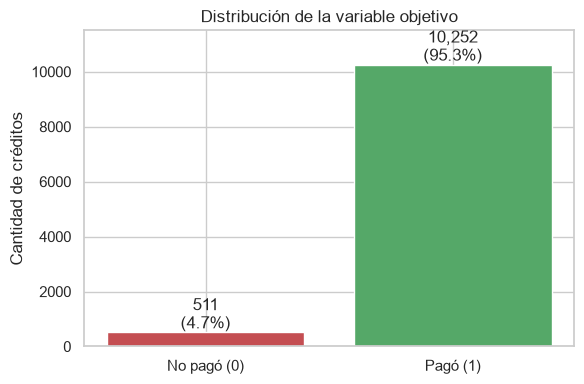

In [105]:
# Calcula la cantidad de registros de cada clase de la variable objetivo.
conteo = (
    df_limpio["Pago_atiempo"]
    .value_counts()
    .sort_index()
)

# Calcula el porcentaje que representa cada clase en el dataset.
pct = (
    df_limpio["Pago_atiempo"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Muestra el conteo y el porcentaje de cada clase.
print(
    pd.DataFrame({
        "cantidad": conteo,
        "porcentaje": pct.round(2)
    })
)

# Crea la figura para representar la distribución de la variable objetivo.
fig, ax = plt.subplots(figsize=(6, 4))

# Dibuja una barra para cada clase:
# 0 corresponde a créditos no pagados y 1 a créditos pagados.
ax.bar(
    ["No pagó (0)", "Pagó (1)"],
    conteo.values,
    color=["#c44e52", "#55a868"]
)

# Añade etiquetas con la cantidad y el porcentaje sobre cada barra.
for i, v in enumerate(conteo.values):
    ax.text(
        i,
        v + 150,
        f"{v:,}\n({pct.values[i]:.1f}%)",
        ha="center"
    )

# Configura el título, el eje Y y el límite superior del gráfico.
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Cantidad de créditos")
ax.set_ylim(0, 11500)

# Ajusta el diseño y muestra el gráfico.
plt.tight_layout()
plt.show()

### Observaciones

De 10.763 créditos, **10.252 se pagaron a tiempo (95,25%) y 511 no (4,75%)**.
Hay veinte créditos pagados por cada impago.

Ese desbalance condiciona dos cosas del modelado:

- **La métrica.** Un modelo que prediga "paga" para todos, sin mirar ninguna
  variable, acierta el 95,25% de las veces y no detecta un solo cliente
  riesgoso. Cualquier accuracy cercana a ese número significa que el modelo no
  aprendió nada. Hay que evaluar con recall y F1 sobre la clase minoritaria, y
  con ROC-AUC.
- **El entrenamiento.** Con 511 impagos el modelo tiene poca evidencia de la
  que aprender el patrón. Habrá que probar técnicas de balanceo o ajuste de
  pesos.

### Análisis univariable — variables numéricas

Se analiza cada variable por separado: su distribución, sus medidas de
tendencia central y dispersión, y qué tan torcida está.

`tipo_credito` y `Pago_atiempo` figuran como enteras pero son categóricas, así
que quedan fuera de este bloque.

**Skew (asimetría)** indica hacia qué lado se corre la distribución. Cerca de 0
es simétrica; positivo significa cola hacia la derecha, es decir unos pocos
valores muy altos que estiran el promedio. **Kurtosis** indica cuántos valores
extremos hay lejos del centro. Los dos sirven para responder qué tipo de
distribución tiene cada variable.

In [106]:
# Define las variables numéricas que se analizarán.
numericas = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "saldo_total",
    "saldo_principal", "creditos_sectorFinanciero",
    "creditos_sectorCooperativo", "creditos_sectorReal",
    "promedio_ingresos_datacredito"
]

# Calcula estadísticas descriptivas para cada variable numérica.
# La transposición coloca cada variable en una fila.
resumen_num = df_limpio[numericas].describe().T

# Añade la asimetría de cada distribución.
resumen_num["skew"] = df_limpio[numericas].skew()

# Añade la curtosis para identificar distribuciones con valores extremos.
resumen_num["kurtosis"] = df_limpio[numericas].kurtosis()

# Redondea los resultados para facilitar su lectura.
resumen_num.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
capital_prestado,10763.0,2434315.00,1.909643e+06,360000.0,1224831.0,1921920.0,3084840.00,4.144415e+07,3.72,35.32
plazo_meses,10763.0,10.58,6.630000e+00,2.0,6.0,10.0,12.00,9.000000e+01,2.46,7.78
edad_cliente,10613.0,42.85,1.195000e+01,19.0,33.0,42.0,52.00,6.900000e+01,0.27,-0.86
salario_cliente,10732.0,17266141.27,3.559886e+08,243798.0,2000000.0,3000000.0,4900000.00,2.200000e+10,43.71,2204.86
total_otros_prestamos,10763.0,6238869.65,1.184183e+08,0.0,500000.0,1000000.0,2000000.00,6.787675e+09,38.46,1719.28
cuota_pactada,10763.0,243617.41,2.104937e+05,23944.0,121041.5,182863.0,287833.50,3.816752e+06,3.79,26.65
puntaje_datacredito,10611.0,791.53,5.143000e+01,7.0,758.0,792.0,826.00,9.990000e+02,-0.99,9.98
cant_creditosvigentes,10763.0,5.73,3.980000e+00,0.0,3.0,5.0,8.00,6.200000e+01,1.80,8.62
huella_consulta,10763.0,4.23,3.060000e+00,0.0,2.0,4.0,6.00,2.900000e+01,1.49,4.00
saldo_total,10607.0,45937.41,1.062698e+05,0.0,2898.0,16178.0,52982.00,5.116066e+06,20.20,789.17


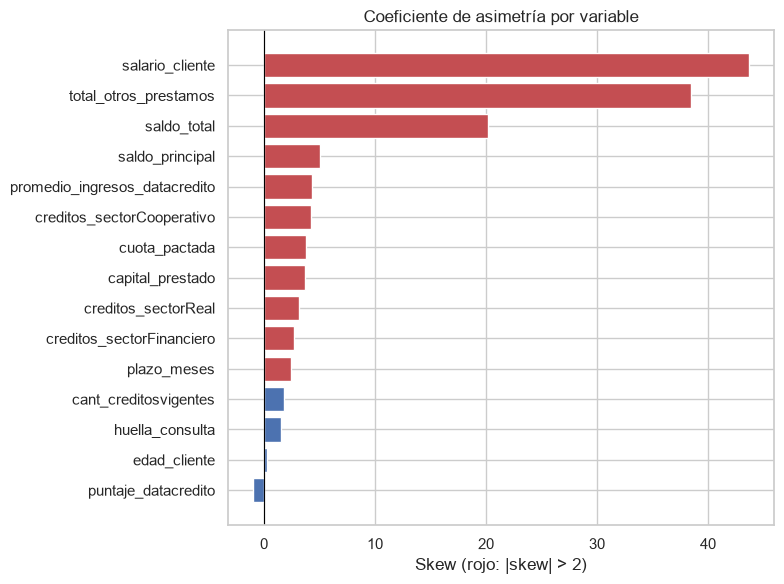

In [107]:
# Calcula la asimetría de cada variable y las ordena de menor a mayor.
skews = df_limpio[numericas].skew().sort_values()

# Crea la figura donde se visualizarán los coeficientes.
fig, ax = plt.subplots(figsize=(8, 6))

# Resalta en rojo las variables con asimetría fuerte, cuyo valor absoluto
# es mayor que 2; las demás se muestran en azul.
colores = [
    "#c44e52" if abs(s) > 2 else "#4c72b0"
    for s in skews.values
]

# Representa los coeficientes mediante barras horizontales.
ax.barh(skews.index, skews.values, color=colores)

# Añade una línea de referencia en cero para distinguir el sentido del sesgo.
ax.axvline(0, color="black", linewidth=0.8)

# Configura el título y la etiqueta del eje horizontal.
ax.set_title("Coeficiente de asimetría por variable")
ax.set_xlabel("Skew (rojo: |skew| > 2)")

# Ajusta el diseño y muestra el gráfico.
plt.tight_layout()
plt.show()

### Observaciones

**Once de las quince variables tienen sesgo fuerte** (|skew| > 2, las rojas del
gráfico). Tres están en otra escala: `salario_cliente` (43,7),
`total_otros_prestamos` (38,5) y `saldo_total` (20,2). Las otras ocho se ubican
entre 2 y 5.

Solo cuatro quedan por debajo de ese umbral:

- `cant_creditosvigentes` (1,8) y `huella_consulta` (1,5) — sesgo moderado.
- `edad_cliente` (0,27) — la única aproximadamente simétrica del dataset.
- `puntaje_datacredito` (-0,99) — la única con sesgo negativo, o sea con cola
  hacia la izquierda. Tiene sentido en un score: la mayoría de la gente puntúa
  alto y unos pocos muy bajo.

**Ninguna variable de monto es gaussiana.** Predomina la forma logarítmica,
característica de las variables de dinero: la mayoría de los valores en el
rango bajo y unos pocos muy por encima.

In [109]:
# Filtra los salarios inferiores a 100.000 y cuenta la frecuencia de cada valor.
salarios_bajos = (
    df_limpio.loc[
        df_limpio["salario_cliente"] < 100_000,
        "salario_cliente"
    ]
    .value_counts()
    .head(10)
)

# Muestra los diez valores más frecuentes dentro de los salarios bajos.
print(salarios_bajos)

Series([], Name: count, dtype: int64)


In [113]:
# Cuenta los salarios que aún están por debajo de 100.000
# después del proceso de limpieza.
print(
    "Salarios menores a 100.000:",
    (df_limpio["salario_cliente"] < 100_000).sum()
)

# Cuenta los puntajes de Datacrédito iguales a cero,
# que se consideran valores faltantes codificados incorrectamente.
print(
    "puntaje_datacredito == 0:",
    (df_limpio["puntaje_datacredito"] == 0).sum()
)

Salarios menores a 100.000: 0
puntaje_datacredito == 0: 0


### Corrección adicional detectada en el análisis univariable

El resumen estadístico dejó a la vista dos mínimos que no son válidos:

- **`salario_cliente`**: 7 registros por debajo de 100.000, el más bajo de
  1.000. Ningún ingreso mensual de ese orden alcanza para acceder a un crédito
  de varios millones.
- **`puntaje_datacredito`**: 145 registros en 0. El score de Datacrédito no
  arranca en cero, así que ese valor no es un puntaje bajo sino ausencia de
  historial.

Los dos casos repiten lo que ya vimos con los 24 salarios en 0: **este dataset
usa el cero como sustituto de dato faltante** en varias columnas. Es
exactamente lo que la consigna pide unificar.

In [115]:
# Convierte los salarios inferiores a 100.000 en valores faltantes,
# ya que se consideran ingresos inválidos para este análisis.
df_limpio.loc[
    df_limpio["salario_cliente"] < 100_000,
    "salario_cliente"
] = np.nan

# Convierte los puntajes iguales a cero en valores faltantes,
# porque representan ausencia de historial y no un puntaje real.
df_limpio.loc[
    df_limpio["puntaje_datacredito"] == 0,
    "puntaje_datacredito"
] = np.nan

# Verifica la cantidad total de nulos después de ambas correcciones.
print(
    f"Nulos salario_cliente:     "
    f"{df_limpio['salario_cliente'].isna().sum()} (antes 24)"
)
print(
    f"Nulos puntaje_datacredito: "
    f"{df_limpio['puntaje_datacredito'].isna().sum()} (antes 7)"
)

Nulos salario_cliente:     31 (antes 24)
Nulos puntaje_datacredito: 152 (antes 7)


In [116]:
# Selecciona las dos variables corregidas para comparar sus distribuciones.
variables_corregidas = [
    "salario_cliente",
    "puntaje_datacredito"
]

# Calcula el valor mínimo, la asimetría y la curtosis de cada variable.
comparacion = pd.DataFrame({
    "min": df_limpio[variables_corregidas].min(),
    "skew": df_limpio[variables_corregidas].skew(),
    "kurtosis": df_limpio[variables_corregidas].kurtosis()
})

# Redondea los resultados para facilitar su lectura.
print(comparacion.round(2))

                          min   skew  kurtosis
salario_cliente      243798.0  43.71   2204.86
puntaje_datacredito       7.0  -0.99      9.98


### Distribución de las variables de monto

Cinco variables en pesos, todas con sesgo positivo fuerte (skew entre 3,7 y
43,7): la mayoría de los valores se concentra abajo y unos pocos llegan muy
alto.

Se grafica cada una dos veces, en escala original y en logarítmica. El
logaritmo comprime la escala —acerca los valores grandes al resto— y sirve para
ver si la distribución se endereza.

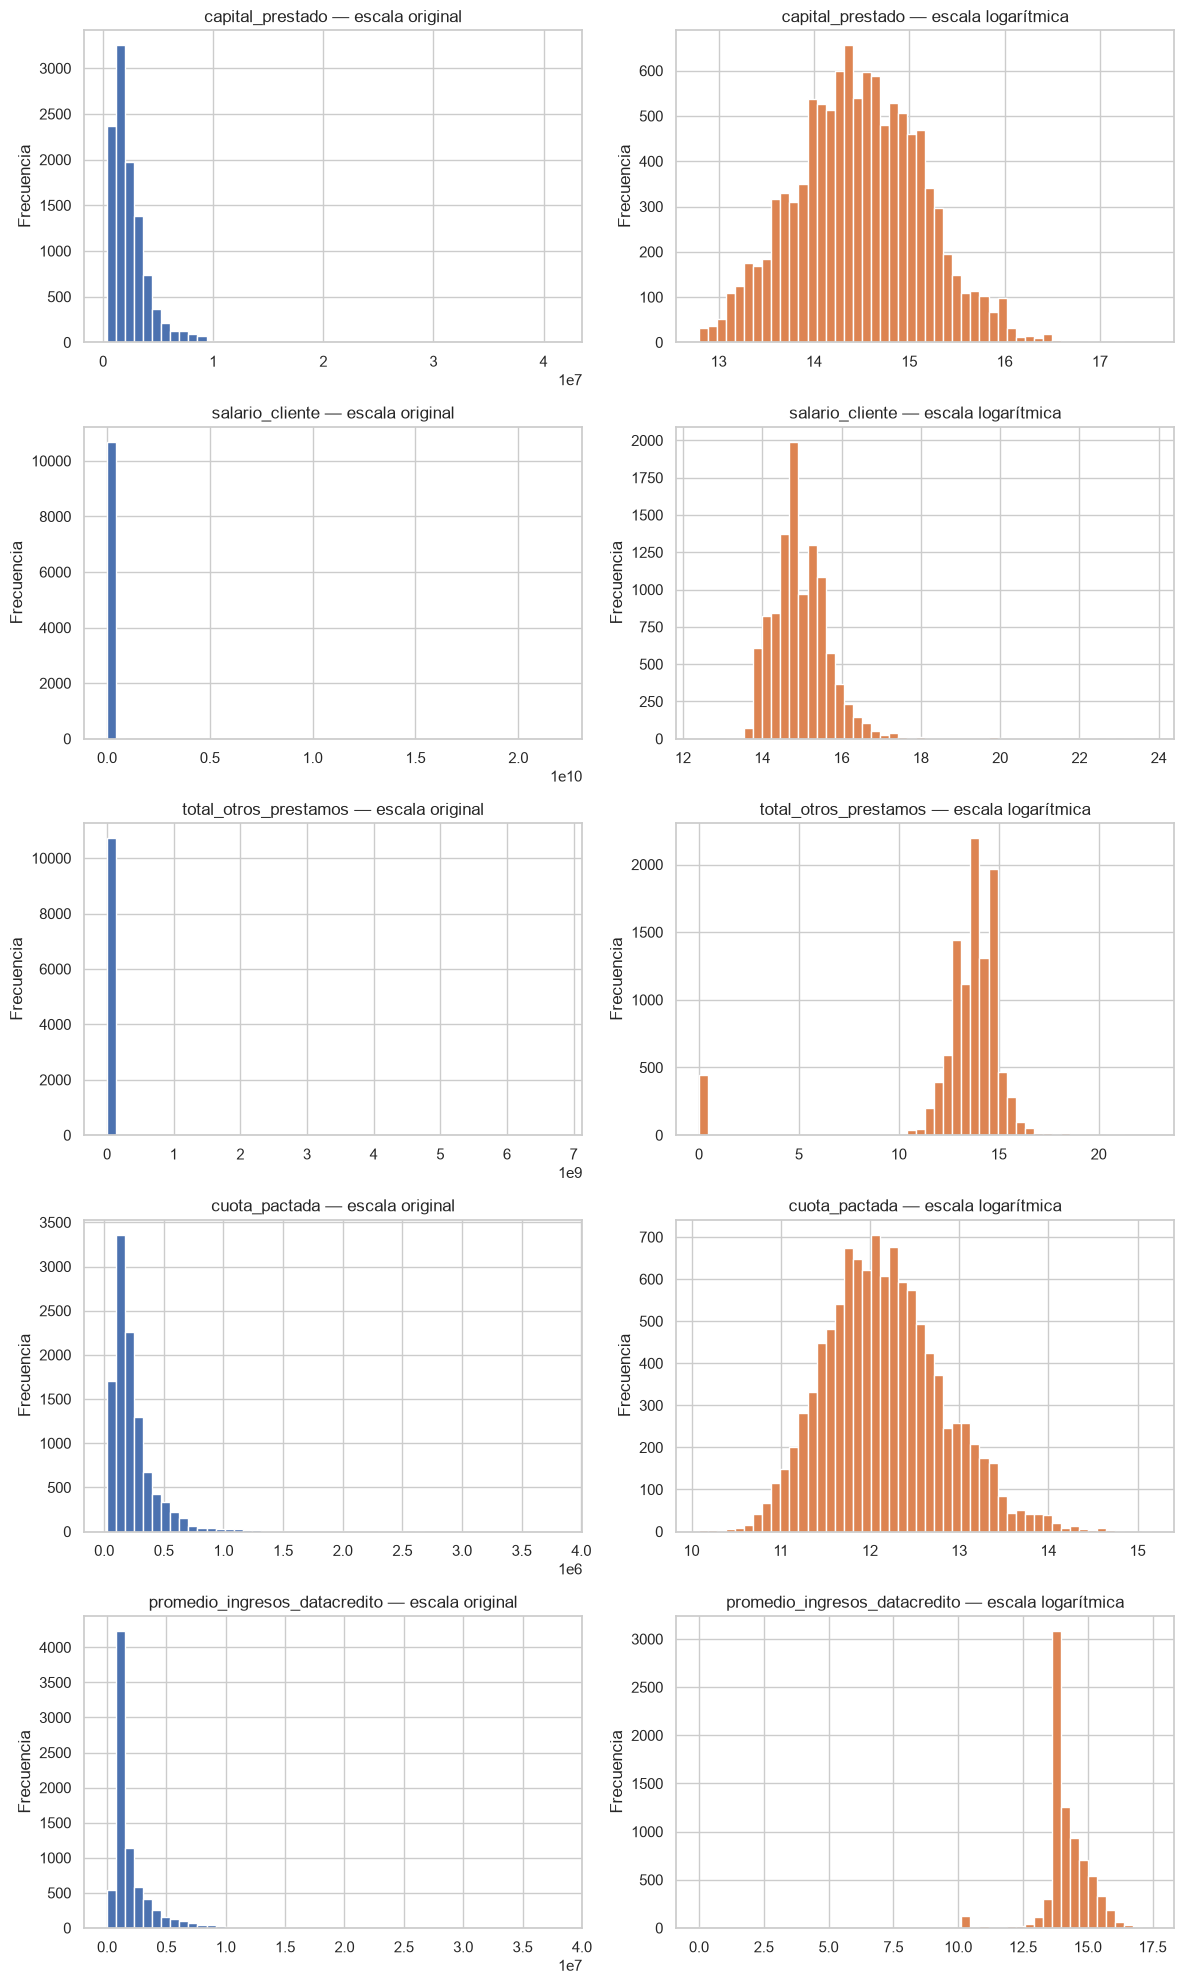

                               skew_original  skew_log
capital_prestado                        3.72      0.11
salario_cliente                        43.71      2.78
total_otros_prestamos                  38.46     -3.61
cuota_pactada                           3.79      0.40
promedio_ingresos_datacredito           4.28     -3.49


In [117]:
# Define las variables monetarias que se analizarán.
montos = [
    "capital_prestado",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada",
    "promedio_ingresos_datacredito"
]

# Crea dos gráficos por variable: escala original y escala logarítmica.
fig, axes = plt.subplots(
    len(montos),
    2,
    figsize=(12, 4 * len(montos))
)

# Genera los histogramas para cada variable monetaria.
for i, col in enumerate(montos):
    # Excluye los valores faltantes antes de realizar las transformaciones.
    datos = df_limpio[col].dropna()

    # Muestra la distribución en su escala original.
    axes[i, 0].hist(
        datos,
        bins=50,
        color="#4c72b0",
        edgecolor="white"
    )
    axes[i, 0].set_title(f"{col} — escala original")
    axes[i, 0].set_ylabel("Frecuencia")

    # Aplica log(1+x), que permite trabajar con valores iguales a cero.
    axes[i, 1].hist(
        np.log1p(datos),
        bins=50,
        color="#dd8452",
        edgecolor="white"
    )
    axes[i, 1].set_title(f"{col} — escala logarítmica")
    axes[i, 1].set_ylabel("Frecuencia")

# Ajusta la distribución de los gráficos y muestra la figura.
plt.tight_layout()
plt.show()

# Compara numéricamente la asimetría antes y después de aplicar el logaritmo.
efecto = pd.DataFrame({
    "skew_original": df_limpio[montos].skew(),
    "skew_log": df_limpio[montos].apply(
        lambda s: np.log1p(s.dropna()).skew()
    )
}).round(2)

print(efecto)

### Observaciones

**El logaritmo funciona en la mayoría de los casos.** `capital_prestado` y
`cuota_pactada` pasan de ser una barra pegada a la izquierda a una campana casi
perfecta.

**`salario_cliente` mejora pero le queda cola.** Después de transformar todavía
se ven valores sueltos entre 18 y 24, separados del cuerpo. Son los registros
por encima de 50 millones: el logaritmo los acerca pero no los integra. Van a
necesitar tratamiento aparte.

**Dos variables tienen un grupo separado en cero.** En escala logarítmica,
`total_otros_prestamos` y `promedio_ingresos_datacredito` muestran una barra
aislada en el extremo izquierdo, sin nada que la conecte con el resto. Son
clientes sin otros préstamos y sin ingresos reportados: no es un valor bajo,
es otra cosa.

El efecto de la transformación, en números:

| Variable | Skew original | Skew log |
|---|---|---|
| `capital_prestado` | 3,72 | 0,11 |
| `cuota_pactada` | 3,79 | 0,40 |
| `salario_cliente` | 43,71 | 2,78 |
| `total_otros_prestamos` | 38,46 | -3,61 |
| `promedio_ingresos_datacredito` | 4,28 | -3,49 |

Las dos últimas cambian de signo. No es que el logaritmo corrigiera de más: al
comprimirse el cuerpo de la distribución, el grupo de ceros queda solo del lado
izquierdo y **pasa a ser la cola**. O sea que ahí el problema no es de escala
sino que hay dos poblaciones distintas conviviendo en la misma columna.

**Implicancia**: queda identificada la transformación logarítmica para los
montos, y la condición "valor en cero" como posible atributo derivado binario.

### Distribución de los saldos

`saldo_total` y `saldo_principal` registran la deuda que el cliente ya tiene en
otras obligaciones. Se analizan juntas porque coinciden en el 83,6% de los
registros.

Se agrega el **boxplot**, que muestra de un vistazo la mediana, el 50% central
de los datos (la caja) y los valores atípicos (los puntos sueltos).

C:\Users\mau93\AppData\Local\Temp\ipykernel_35788\1652134073.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_35788\1652134073.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)


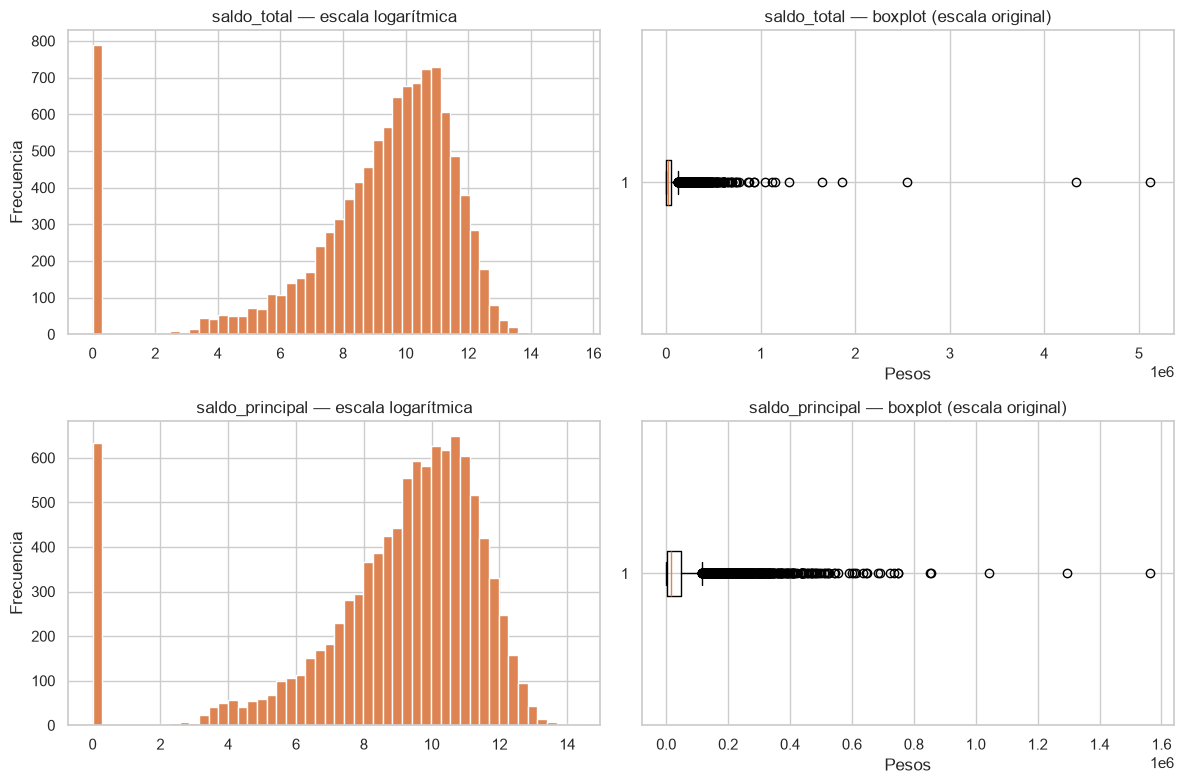

Registros en cero:
  saldo_total: 789 (7.4%)
  saldo_principal: 633 (6.1%)


In [118]:
# Define los saldos que se analizarán conjuntamente.
saldos = ["saldo_total", "saldo_principal"]

# Crea dos gráficos por saldo: histograma logarítmico y boxplot original.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Genera los gráficos para cada variable de saldo.
for i, col in enumerate(saldos):
    # Excluye los valores faltantes antes de graficar.
    datos = df_limpio[col].dropna()

    # Representa la distribución en escala logarítmica.
    axes[i, 0].hist(
        np.log1p(datos),
        bins=50,
        color="#dd8452",
        edgecolor="white"
    )
    axes[i, 0].set_title(f"{col} — escala logarítmica")
    axes[i, 0].set_ylabel("Frecuencia")

    # Usa un boxplot para observar mediana, cuartiles y valores extremos.
    axes[i, 1].boxplot(datos, vert=False)
    axes[i, 1].set_title(f"{col} — boxplot (escala original)")
    axes[i, 1].set_xlabel("Pesos")

# Ajusta el diseño y muestra los gráficos.
plt.tight_layout()
plt.show()

# Cuenta y calcula el porcentaje de registros con saldo igual a cero.
print("Registros en cero:")
for col in saldos:
    ceros = (df_limpio[col] == 0).sum()
    total_validos = df_limpio[col].notna().sum()
    porcentaje_ceros = ceros / total_validos * 100

    print(
        f"  {col}: {ceros} "
        f"({porcentaje_ceros:.1f}%)"
    )

### Observaciones

Los dos saldos repiten la estructura de `total_otros_prestamos`: **una barra
aislada en cero** —790 registros en `saldo_total` y 630 en `saldo_principal`—
separada del cuerpo de la distribución, que en escala logarítmica queda como
una campana centrada entre 10 y 11.

Esos registros en cero son clientes sin deuda vigente reportada, que es una
condición distinta a tener un saldo bajo.

Los boxplots muestran hasta qué punto están sesgadas: la caja es tan chica que
apenas se distingue, y hay una nube densa de puntos que se extiende hasta 5,1
millones en `saldo_total` y 1,6 millones en `saldo_principal`.

**Implicancia**: ya van cuatro variables con la misma estructura
—`total_otros_prestamos`, `promedio_ingresos_datacredito`, `saldo_total` y
`saldo_principal`—. Es un patrón del dataset, no una casualidad, y todas piden
el mismo tratamiento: logaritmo para el cuerpo más un indicador binario que
marque la ausencia.

### Distribución de las variables de conteo

Cinco variables que cuentan cosas: créditos vigentes, consultas al historial y
créditos por sector. Son números enteros con un rango chico (de 0 a 62 en el
caso más amplio), así que se grafican en escala original —no hace falta
logaritmo— y con una barra por cada valor posible, para que se lea cuántos
clientes tienen exactamente cada cantidad.

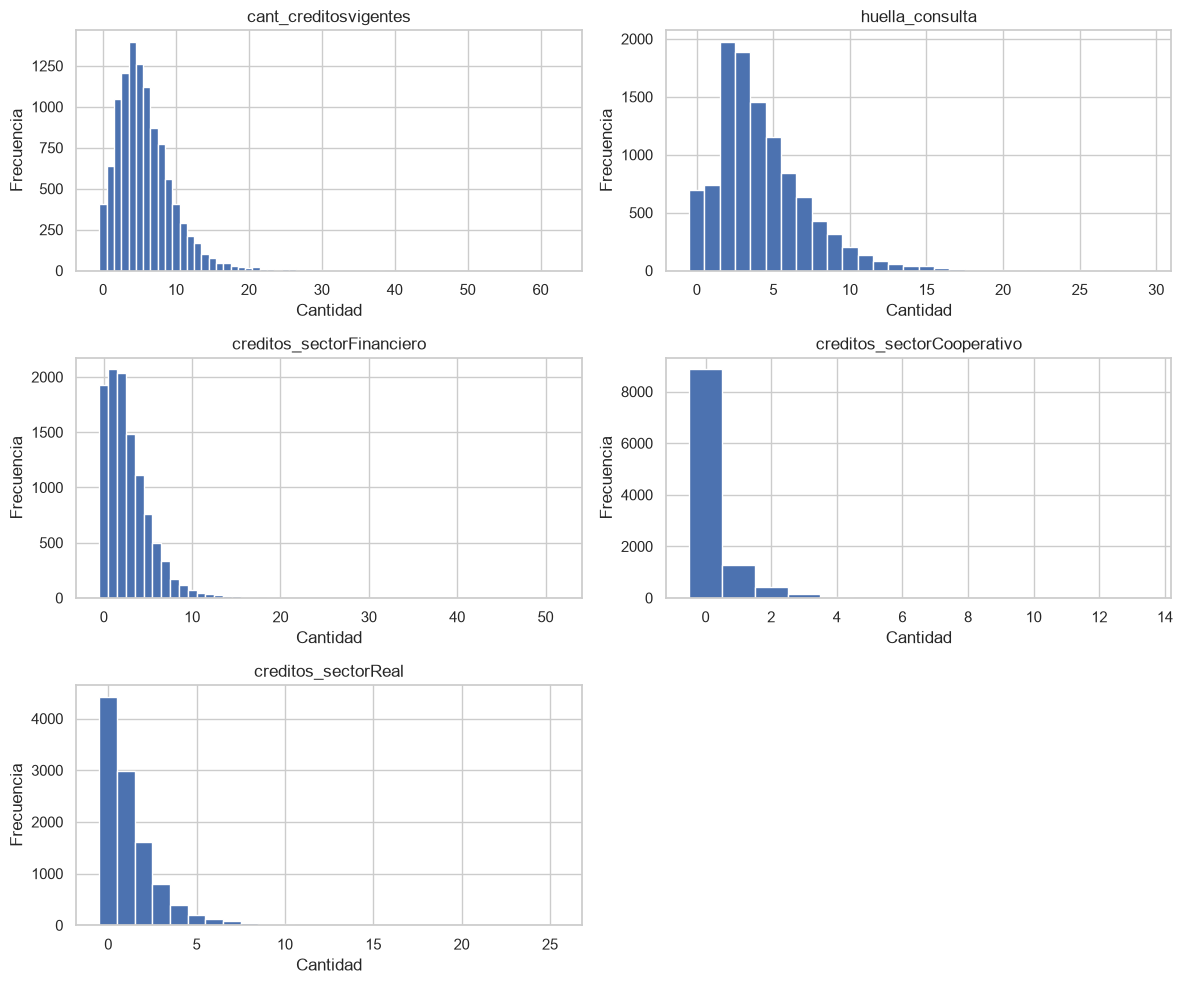

Registros en cero:
  cant_creditosvigentes             405 (  3.8%)
  huella_consulta                   700 (  6.5%)
  creditos_sectorFinanciero        1924 ( 17.9%)
  creditos_sectorCooperativo       8868 ( 82.4%)
  creditos_sectorReal              4426 ( 41.1%)


In [119]:
# Define las variables de conteo que se analizarán.
conteos = [
    "cant_creditosvigentes",
    "huella_consulta",
    "creditos_sectorFinanciero",
    "creditos_sectorCooperativo",
    "creditos_sectorReal"
]

# Crea una cuadrícula de seis espacios para mostrar cinco histogramas.
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Genera un histograma para cada variable de conteo.
for i, col in enumerate(conteos):
    datos = df_limpio[col]

    # Usa un intervalo por cada valor entero para evitar agrupar categorías.
    axes[i].hist(
        datos,
        bins=range(0, int(datos.max()) + 2),
        color="#4c72b0",
        edgecolor="white",
        align="left"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Cantidad")
    axes[i].set_ylabel("Frecuencia")

# Oculta el sexto panel porque no corresponde a ninguna variable.
axes[5].axis("off")

# Ajusta el diseño y muestra los histogramas.
plt.tight_layout()
plt.show()

# Calcula la cantidad y el porcentaje de clientes con valor cero.
print("Registros en cero:")
for col in conteos:
    ceros = (df_limpio[col] == 0).sum()
    porcentaje_ceros = ceros / len(df_limpio) * 100

    print(
        f"  {col:30} "
        f"{ceros:6} "
        f"({porcentaje_ceros:5.1f}%)"
    )

### Observaciones

`cant_creditosvigentes` y `huella_consulta` son las más regulares del dataset:
suben hasta un pico —en 4-5 y 2-3 respectivamente— y bajan de a poco. Sus skew
(1,8 y 1,5) son los más bajos del grupo.

`creditos_sectorFinanciero` sigue el mismo patrón con pico en 1-2.

**`creditos_sectorCooperativo` es casi constante**: alrededor del 82% de los
clientes está en cero. Con esa poca variabilidad, distingue muy poco entre
clientes. No la eliminamos todavía porque, a diferencia de las que sacamos por
fuga, esta es información del historial previo y sí está disponible cuando
llega una solicitud. Queda para ver en el bivariable si el 18% que sí tiene
créditos cooperativos se comporta distinto.

`creditos_sectorReal` también concentra en cero pero se distribuye más.

### Distribución de scores y variables demográficas

Tres variables de naturaleza distinta a las anteriores: la edad del cliente, el
score externo de Datacrédito y el plazo del crédito.

C:\Users\mau93\AppData\Local\Temp\ipykernel_35788\2748554234.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_35788\2748554234.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)
C:\Users\mau93\AppData\Local\Temp\ipykernel_35788\2748554234.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(datos, vert=False)


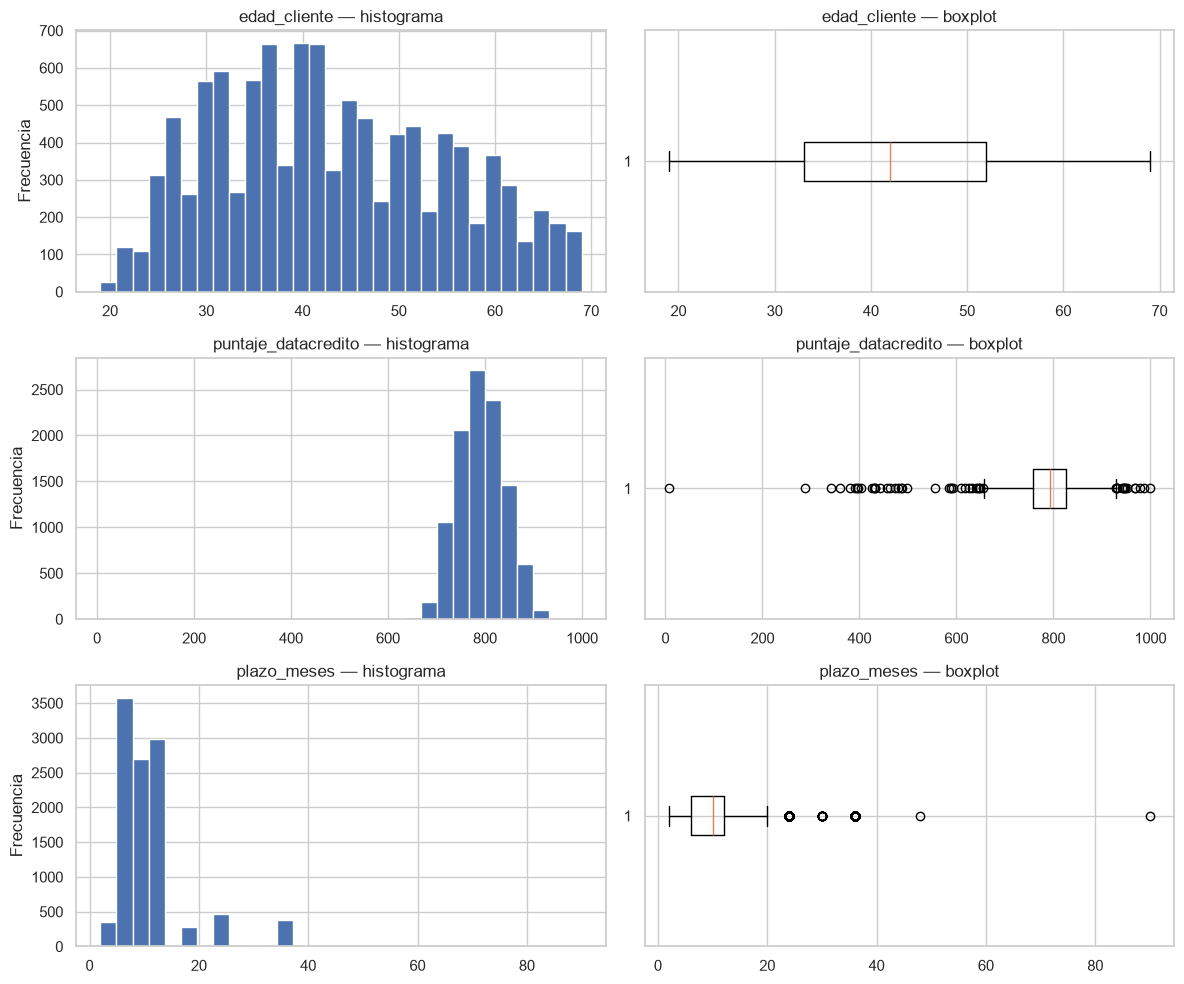

                       count    mean    std   min    25%    50%    75%    max
edad_cliente         10613.0   42.85  11.95  19.0   33.0   42.0   52.0   69.0
puntaje_datacredito  10611.0  791.53  51.43   7.0  758.0  792.0  826.0  999.0
plazo_meses          10763.0   10.58   6.63   2.0    6.0   10.0   12.0   90.0


In [120]:
# Define las variables demográficas y de características del crédito.
otras = [
    "edad_cliente",
    "puntaje_datacredito",
    "plazo_meses"
]

# Crea dos gráficos por variable: histograma y boxplot.
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Genera los gráficos y las estadísticas de cada variable.
for i, col in enumerate(otras):
    # Excluye los valores faltantes antes de graficar.
    datos = df_limpio[col].dropna()

    # Muestra la distribución de frecuencias mediante un histograma.
    axes[i, 0].hist(
        datos,
        bins=30,
        color="#4c72b0",
        edgecolor="white"
    )
    axes[i, 0].set_title(f"{col} — histograma")
    axes[i, 0].set_ylabel("Frecuencia")

    # Muestra la mediana, los cuartiles y los posibles valores extremos.
    axes[i, 1].boxplot(datos, vert=False)
    axes[i, 1].set_title(f"{col} — boxplot")

# Ajusta el diseño y muestra los gráficos.
plt.tight_layout()
plt.show()

# Genera estadísticas descriptivas para comparar las variables.
print(
    df_limpio[otras]
    .describe()
    .T
    .round(2)
)

### Observaciones

**`edad_cliente` es la única con distribución normal** (skew 0,27). Va de 19 a
69 años y se concentra entre 30 y 45. Su boxplot no tiene ni un punto de
outlier, único caso en todo el dataset — confirma que la corrección de los 150
registros mayores de 90 años funcionó.

**`puntaje_datacredito` concentra entre 700 y 900.** Es la única variable con
sesgo negativo (-0,99): sus valores atípicos están por debajo del rango
habitual, no por encima. En el boxplot los puntos sueltos aparecen a la
izquierda, al revés que en todas las demás. Coherente con un score, donde la
mayoría puntúa bien y una minoría muy mal.

**`plazo_meses` no es una variable continua.** Tiene dos regímenes:

- Hasta 12 meses aparecen todos los valores enteros, pero concentrados en los
  plazos habituales: 6 meses (3.326 créditos), 12 (2.658) y 10 (1.520) reúnen
  el 70% del total. Los intermedios existen pero pesan poco — 7 meses tiene 22
  casos.
- Por encima de 12 solo hay valores redondos: 18 (275), 24 (464) y 36 (385),
  más casos aislados de 20, 30, 48 y 90. Los dos últimos tienen un registro
  cada uno.

**Implicancia**: `plazo_meses` se comporta como ordinal con pocos niveles, y
podría tratarse como categórica en lugar de continua.

### Distribución de las variables categóricas

Tres variables: `tipo_laboral` (dos categorías), `tipo_credito` (códigos
numéricos) y `tendencia_ingresos` (con la categoría `valor_anomalo` que
agregamos en la limpieza).

Los nulos se incluyen en el conteo a propósito: `tendencia_ingresos` tiene un
27% de faltantes, y ocultarlos daría una idea falsa de cómo se reparte.

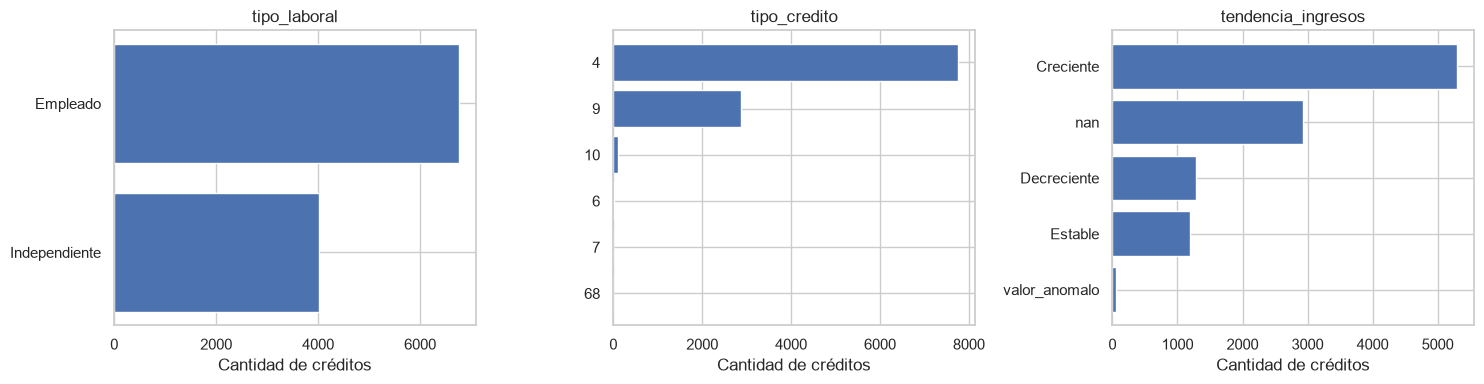


--- tipo_laboral ---
tipo_laboral
Empleado         62.75
Independiente    37.25
Name: proportion, dtype: float64

--- tipo_credito ---
tipo_credito
4     71.98
9     26.72
10     1.08
6      0.20
7      0.02
68     0.01
Name: proportion, dtype: float64

--- tendencia_ingresos ---
tendencia_ingresos
Creciente        49.19
NaN              27.24
Decreciente      11.99
Estable          11.04
valor_anomalo     0.54
Name: proportion, dtype: float64


In [121]:
# Define las variables categóricas que se analizarán.
categoricas = [
    "tipo_laboral",
    "tipo_credito",
    "tendencia_ingresos"
]

# Crea un gráfico para cada variable categórica.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Genera gráficos de barras horizontales con la frecuencia de cada categoría.
for i, col in enumerate(categoricas):
    # Incluye los valores nulos para representar toda la distribución.
    conteo = (
        df_limpio[col]
        .value_counts(dropna=False)
        .sort_values()
    )

    # Convierte las categorías a texto para utilizarlas como etiquetas.
    etiquetas = [str(x) for x in conteo.index]

    axes[i].barh(
        etiquetas,
        conteo.values,
        color="#4c72b0"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Cantidad de créditos")

# Ajusta el diseño y muestra los gráficos.
plt.tight_layout()
plt.show()

# Imprime el porcentaje que representa cada categoría.
for col in categoricas:
    print(f"\n--- {col} ---")

    porcentajes = (
        df_limpio[col]
        .value_counts(dropna=False, normalize=True)
        .round(4)
        * 100
    )

    print(porcentajes)

### Observaciones

**`tipo_laboral` es la mejor repartida:** Empleado 6.754 (62,75%) e
Independiente 4.009 (37,25%), sin faltantes.

**`tipo_credito` está dominada por dos categorías.** El tipo 4 se lleva el
71,98% y el tipo 9 el 26,72%: entre los dos, el 98,7%. Los otros cuatro —10
(1,08%), 6 (0,20%), 7 (0,02%) y 68 (0,01%)— suman 140 registros. Categorías tan
chicas pueden quedar enteras de un lado al dividir los datos, o dar
estimaciones inestables.

**En `tendencia_ingresos` los faltantes son la segunda categoría más
frecuente.** Creciente encabeza con 49,19%, después vienen los nulos con
27,24% —más que Decreciente (11,99%) y Estable (11,04%) por separado— y al
final `valor_anomalo` con 0,54%.

Llama la atención que casi la mitad de los clientes tenga tendencia Creciente.
Contando solo los que tienen dato, son el 67%. Podría reflejar la política de
otorgamiento —prestarle preferentemente a gente con ingresos en alza— o algo
del armado del dataset. No hay forma de distinguirlo acá.

**Implicancia**: las categorías minoritarias de `tipo_credito` podrían
agruparse en una categoría "otros" antes del modelado.